In [ ]:
# clustering 

%load_ext autoreload
%autoreload 2
CUDA_VISIBLE_DEVICES=1

import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import argparse
import torch


#from tqdm.notebook import tqdm, trange
from tqdm import tqdm, trange

from models.classification_ood_tetection import (
    classification_ood_tetection, 
    MyDataset,
    my_collate_fn,
    my_collate_fn_rationale,
    load_sst
)

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--gpu", type=str, default="1")
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument(
        "--val_filename",
        type=str,
        default="clustering/finetuned.txt"
        
    )
    parser.add_argument(
        "--val_rationale",
        type=str,
        default="datasets/eSNLI/esnli_test.rationale_idx"
    )
    
    parser.add_argument(
        "--token_cls", 
        action='store_true'
    )
    
    parser.add_argument(
        "--model_path",
        type=str,
        default="outputs/ood_detection/epoch=11-val_acc=0.9656-val_f1=0.9414.ckpt"
    )
    
    parser.add_argument(
        "--dataset",
        type=str,
        default="coco", # coco, esnli
    )

    hparams, _ = parser.parse_known_args()
    
    # 환경 변수 설정
    os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
    os.environ["CUDA_VISIBLE_DEVICES"] = hparams.gpu

    # GPU 할당
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

model = classification_ood_tetection.load_from_checkpoint(hparams.model_path).to(device) # 내가 원하는 형태로 output만 뽑기
model.hparams.model_path = hparams.model_path

model.freeze()
model.prepare_data()
print("Current CUDA device index:", torch.cuda.current_device())

In [ ]:
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
import torch.nn.functional as F

# softmax with temperature scaling
def softmax_with_temperature(logits, T):
    logits = logits / T  # Temperature scaling
    max_logits = torch.max(logits, dim=1, keepdim=True)[0]
    exp_logits = torch.exp(logits - max_logits)
    sum_exp_logits = torch.sum(exp_logits, dim=1, keepdim=True)
    y = exp_logits / sum_exp_logits
    return y

T = 1000 
epsilon = 0.033
probability_threshold = 0.071486


val_dataset, _ = load_sst(
                hparams.val_filename, None, hparams.dataset, model.hparams.num_labels, hparams.val_rationale, model.hparams.token_cls
            )
val_dataloader = torch.utils.data.DataLoader(
            val_dataset, batch_size=1, collate_fn=my_collate_fn_rationale, num_workers=8
        )

selected_clustering_values = []
selected_clustering_indices = []
selected_premises = []
selected_hypotheses = []
selected_cls_embeddings = []  # cls embedding save


for i, batch in tqdm(enumerate(model.val_dataloader()), total=len(model.val_dataset) // model.hparams.batch_size): # Coco
    model.eval()
    inputs = model.tokenizer.batch_encode_plus(batch[0], pad_to_max_length=True, return_tensors='pt').to(device)
    input_ids = inputs['input_ids']
    mask = inputs['attention_mask']
    token_type_ids = inputs['token_type_ids']
    labels = batch[1].to(device)
    
    logits, new_logits, cls_embedding = model.forward(input_ids, mask, token_type_ids, temperature=T, epsilon=epsilon)  # add cls_embedding

    model.zero_grad()
    
    # new_logits
    softmaxed_clustering_output = F.softmax(new_logits, dim=1) 
    
    max_values_clustering, max_indices_clustering = torch.max(softmaxed_clustering_output, dim=1)
    
    for j in range(len(max_values_clustering)):
        if max_values_clustering[j] <= probability_threshold:
            selected_clustering_indices.append(max_indices_clustering[j].detach().cpu().numpy())
            selected_clustering_values.append(max_values_clustering[j].detach().cpu().numpy())
            
            
            premise, hypothesis = batch[0][j]
            
            selected_premises.append(premise.strip())
            selected_hypotheses.append(hypothesis.strip())
            
         
            selected_cls_embeddings.append(cls_embedding[j].detach().cpu().numpy())  # CLS 토큰 임베딩 추가


results_df = pd.DataFrame({
    'Indices': selected_clustering_indices,
    'Probabilities': selected_clustering_values,
    'Premise': selected_premises,
    'Hypothesis': selected_hypotheses,
    'CLS_Embedding': selected_cls_embeddings  # cls embedding 추가
})


results_df.to_excel('clustering/output_sorted.xlsx', index=False)


num_selected_rows = len(selected_clustering_values)
print(f"Number of rows saved: {num_selected_rows}")


8585it [25:20,  5.65it/s]                          


Number of rows saved: 54913


In [ ]:


import pandas as pd
import os
import glob


cluster_output_dir = 'ood_detection/clustering/cluster_output_5000/'


cluster_files = glob.glob(os.path.join(cluster_output_dir, 'output_cluster_*.xlsx'))


results = []
for file in cluster_files:
    df = pd.read_excel(file)
    index_counts = df['Indices'].value_counts()
    most_common_index = index_counts.idxmax()
    most_common_index_count = index_counts.max()
    total_indices = len(df)
    most_common_index_ratio = most_common_index_count / total_indices * 100
    
    results.append({
        'file' : os.path.basename(file),
        'most_common_index' : most_common_index,
        'most_common_index_count' : most_common_index_count,
        'total_indices' : total_indices,
        'most_common_index_ratio' : most_common_index_ratio
    })
    

results_df = pd.DataFrame(results)


print(results_df)


results_df = results_df.sort_values(by='most_common_index_ratio', ascending=False)


results_df.to_excel('ood_detection/clustering/cluster_analysis_5000_results.xlsx', index=False)

                          file  most_common_index  most_common_index_count  \
0     output_cluster_3763.xlsx                 10                        2   
1     output_cluster_2207.xlsx                  7                        2   
2     output_cluster_4463.xlsx                  2                        3   
3     output_cluster_2667.xlsx                 10                        3   
4     output_cluster_4195.xlsx                  5                        2   
...                        ...                ...                      ...   
4995  output_cluster_3424.xlsx                  7                        2   
4996   output_cluster_378.xlsx                  3                       20   
4997  output_cluster_1528.xlsx                  7                        5   
4998  output_cluster_4029.xlsx                  5                       14   
4999   output_cluster_222.xlsx                  5                       16   

      total_indices  most_common_index_ratio  
0               

/home/hjy/anaconda3/envs/diff/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Number of clusters: 1000
Cluster 478: 187 rows
Cluster 205: 162 rows
Cluster 165: 157 rows
Cluster 257: 156 rows
Cluster 791: 153 rows
Cluster 890: 146 rows
Cluster 233: 144 rows
Cluster 892: 141 rows
Cluster 341: 140 rows
Cluster 471: 139 rows
Cluster 116: 136 rows
Cluster 544: 136 rows
Cluster 456: 135 rows
Cluster 234: 134 rows
Cluster 282: 134 rows
Cluster 219: 134 rows
Cluster 57: 133 rows
Cluster 642: 132 rows
Cluster 346: 129 rows
Cluster 582: 129 rows
Cluster 843: 126 rows
Cluster 424: 126 rows
Cluster 260: 125 rows
Cluster 849: 125 rows
Cluster 25: 124 rows
Cluster 213: 123 rows
Cluster 884: 123 rows
Cluster 676: 121 rows
Cluster 221: 120 rows
Cluster 315: 119 rows
Cluster 528: 116 rows
Cluster 100: 116 rows
Cluster 220: 116 rows
Cluster 27: 114 rows
Cluster 778: 113 rows
Cluster 197: 112 rows
Cluster 423: 111 rows
Cluster 717: 111 rows
Cluster 174: 109 rows
Cluster 222: 108 rows
Cluster 906: 107 rows
Cluster 554: 107 rows
Cluster 391: 106 rows
Cluster 496: 106 rows
Cluster 25

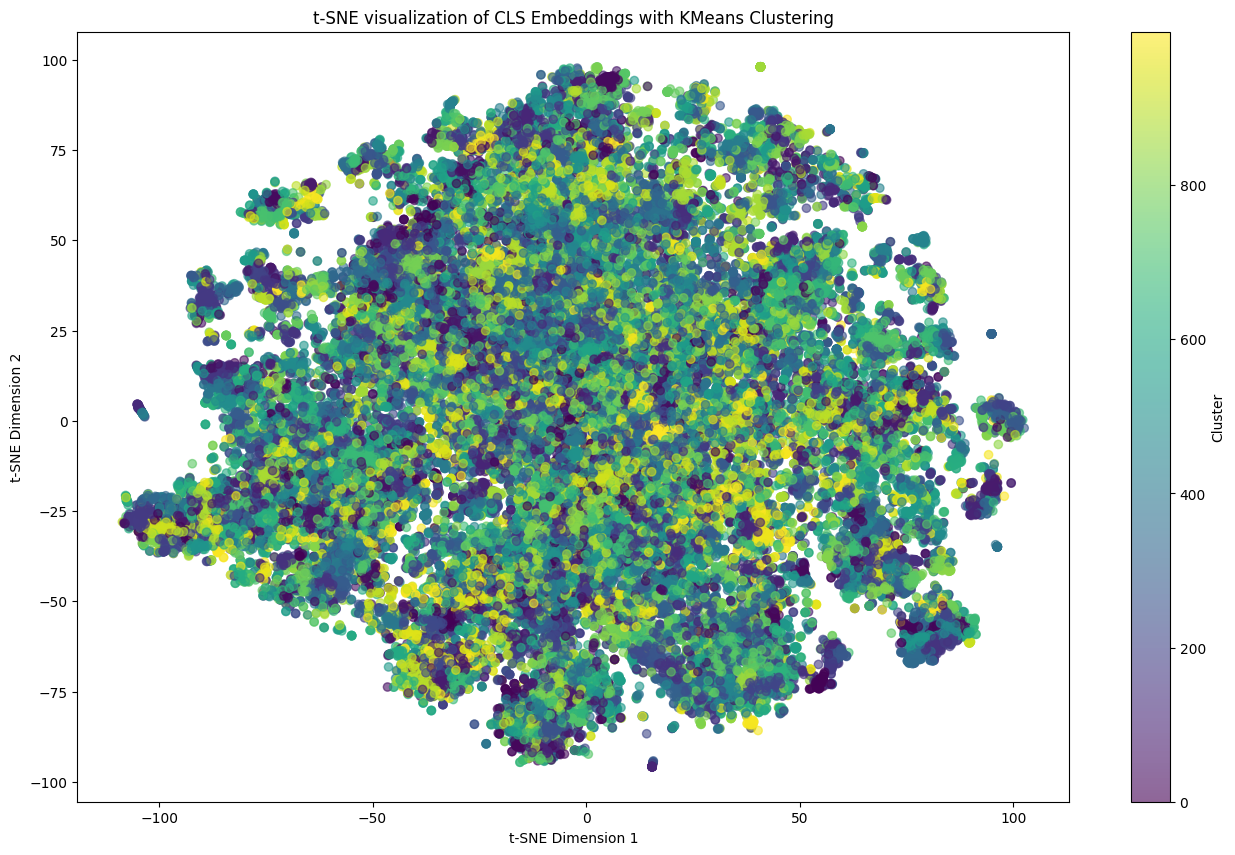

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import re


input_file = 'ood_detection/clustering/output_sort_51914_cls.xlsx'
results_df = pd.read_excel(input_file)


def preprocess_embedding(embedding_str):
    
    embedding_str = re.sub(r'(?<=\d)\s+(?=-?\d)', ', ', embedding_str.strip())
    return np.array(eval(embedding_str))


cls_embeddings = results_df['CLS_Embedding'].apply(preprocess_embedding).tolist()
cls_embeddings = np.stack(cls_embeddings)


num_clusters = 1000  
kmeans = KMeans(n_clusters=num_clusters, random_state=0)
clusters = kmeans.fit_predict(cls_embeddings)


results_df['Cluster'] = clusters


for cluster_num in range(num_clusters):
    cluster_df = results_df[results_df['Cluster'] == cluster_num]
    cluster_df.to_excel(f'ood_detection/clustering/cluster_output_1000/output_cluster_{cluster_num}.xlsx', index=False)


cluster_sizes = results_df['Cluster'].value_counts().sort_values(ascending=False)


print(f"Number of clusters: {num_clusters}")
for cluster_num, size in cluster_sizes.iteritems():
    print(f"Cluster {cluster_num}: {size} rows")


perplexity = min(30, len(cls_embeddings) // 2)
tsne = TSNE(n_components=2, random_state=0, perplexity=perplexity)
tsne_result = tsne.fit_transform(cls_embeddings)


results_df['tsne-2d-one'] = tsne_result[:, 0]
results_df['tsne-2d-two'] = tsne_result[:, 1]


plt.figure(figsize=(16,10))
scatter = plt.scatter(results_df['tsne-2d-one'], results_df['tsne-2d-two'], c=results_df['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')


plt.title('t-SNE visualization of CLS Embeddings with KMeans Clustering')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()


In [ ]:


import pandas as pd
import os
import glob


cluster_output_dir = 'ood_detection/clustering/cluster_output_10000/'

cluster_files = glob.glob(os.path.join(cluster_output_dir, 'output_cluster_*.xlsx'))

results = []
for file in cluster_files:
    df = pd.read_excel(file)
    index_counts = df['Indices'].value_counts()
    most_common_index = index_counts.idxmax()
    most_common_index_count = index_counts.max()
    total_indices = len(df)
    most_common_index_ratio = most_common_index_count / total_indices * 100
    
    results.append({
        'file' : os.path.basename(file),
        'most_common_index' : most_common_index,
        'most_common_index_count' : most_common_index_count,
        'total_indices' : total_indices,
        'most_common_index_ratio' : most_common_index_ratio
    })
    

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by='most_common_index_ratio', ascending=False)

results_df.to_excel('ood_detection/clustering/cluster_analysis_10000_results.xlsx', index=False)

                          file  most_common_index  most_common_index_count  \
0     output_cluster_3763.xlsx                  3                        1   
1     output_cluster_8279.xlsx                 10                        1   
2     output_cluster_9640.xlsx                 10                        2   
3     output_cluster_2207.xlsx                  3                       29   
4     output_cluster_4463.xlsx                  3                        2   
...                        ...                ...                      ...   
9995  output_cluster_1528.xlsx                 10                        5   
9996  output_cluster_6888.xlsx                  3                        1   
9997  output_cluster_4029.xlsx                  1                        1   
9998   output_cluster_222.xlsx                  1                        2   
9999  output_cluster_9173.xlsx                  1                        1   

      total_indices  most_common_index_ratio  
0               